---
title: "LightningCast: Satellite Based Lightning Nowcasting with DEFAIR"
subtitle: "A Destination Earth / DEFAIR use case : A Deep-Learning Model adaptation for Satellite-Based Lightning Nowcasting"
author: "Author: Alejandro Fonseca (EUMETSAT/Starion)"
tags: [DEFAIR, HDA, MTG, FCI L1C, GII, LI AF]
thumbnail: img/EUMETSAT-icon.png
license: MIT
copyright: "© 2026 EUMETSAT"
---



<div style="margin: 6px 0;">
  <a href="https://jupyter.central.data.destination-earth.eu/user-redirect/lab/tree/DestinE-DataLake-Lab/DEFAIR/LightningCast_prediction_using_defair_and_deep_learning.ipynb" target="_blank" style="text-decoration: none;">
    <span class="launch">🚀 Launch in JupyterHub</span>
  </a>
</div>

# CONTENTS

## Introduction & scientific background

Lightning is one of the most immediate hazards produced by convective storms. Airport ground
operations stop when lightning approaches, outdoor events must be evacuated, and power and
telecommunication infrastructure is exposed. For all of these decisions the valuable time
horizon normally is the **next hour** of the event, a timeframe known as *nowcasting*. 
Numerical weather models are too coarse and too slow to refresh for such task, but geostationary satellites observe the full
Earth disk **every 10 minutes**, which makes them the natural instrument for nowcasting and monitoring this hazard.

Cintineo et al. (2022) demonstrated with the USA GOES R satellites that a convolutional
neural network can learn to predict the probability of lightning in the next 60
minutes directly from geostationary imagery, using the satellite's own lightning sensor as
the source of truth (*ProbSevere LightningCast*, Weather and Forecasting, 37(7),
DOI: [10.1175/WAF D 22 0019.1](https://doi.org/10.1175/WAF-D-22-0019.1)).

This notebook adapts that concept to Europe using Meteosat Third Generation (MTG), the
first European geostationary platform that carries both an imager and a dedicated lightning
sensor. The lightning nowcasting application, however, is the vehicle rather than the goal:
the primary objective of this notebook is to demonstrate how DEFAIR operates to combine 
heterogeneous satellite products into a single analysis ready ("AI-ready") data cube.

## Data Sources

MTG carries the three products this notebook combines: the **FCI** (Flexible Combined
Imager, the imaging instrument), the **GII** (Global Instability Index, a Level 2 product
derived from the FCI) and the **LI AF** (Lightning Imager, Accumulated Flashes, the dedicated
lightning sensor and its flash accumulation product).

| Product | Instrument | What it measures | Native form | Role here |
|---|---|---|---|---|
| **FCI L1C**  | Flexible Combined Imager  (channels `ir_105`, `ir_123`)| Thermal infrared radiance, converted to cloud top **brightness temperature** [K] | Full disk every 10 min, 2 km IR grid, delivered as ~40 spatial *chunk* files per cycle | Predictor: storm structure and cloud top evolution |
| **GII**  | Global Instability Index, Derived from FCI (Level 2) | **Atmospheric instability indices** (e.g. Lifted Index, K index) describing how prone the environment is to convection | Every 10 min on a coarser segment grid (~6 km), one file per cycle | Predictor: the pre convective environment |
| **LI AF**  | Lightning Imager, Accumulated Flashes | **Accumulated optical flash detections** | `Twenty 30-second` accumulation grids per 10 min file, 2 km grid | Truth: where lightning actually occurred |

## Study area and episodes

The study area is **NE Italy, the Po Valley and the northern Adriatic**
(bounding box 8.0 to 17.0°E, 43.5 to 47.5°N), one of the most lightning active regions of
Europe. From a full season lightning scanning, we use a time series from  `May to October 2025 `, selecting
the **9 most active convective days (episodes)** . Each episode covers the convective window from
**12:00 to 18:00 UTC**  producing 36 slots of 10 min each (episode = 1 slot every 10min -> 6 slot per hour x 6h ).
Eight episodes are reserved for model training and one (2025 09 16, temporally isolated from the rest) for testing.

## The role of DEFAIR

Preparing these three products for joint analysis normally requires source specific code for
every step: different readers, different coordinate systems, different regridding logic.
DEFAIR replaces that with **one reading interface** (`Dataset.from_source`) and a small set of
**named transformations** (`spatial_filter`, `reprojection`, `temporal_filter` and `alignment`)
that behave identically **regardless of the source**. A dedicated section shows this pipeline end to
end.

## Ouput

By the end of this notebook, the user will have followed the complete journey from raw satellite files to a working nowcasting prototype. Three concrete outputs mark the way: an AI ready data cube that harmonizes the three MTG products onto one grid and one time axis, built with DEFAIR; a set of figures that turn the cube into insight, from the anatomy of a single storm to the inputs the model sees; and a trained U Net that produces, for every location in the study area, a map of the probability of lightning in the coming hour


## Prerequisites

Everything the notebook needs is defined once, here. Nothing later in the notebook defines configuration of
its own.

In [1]:
import os
import time
from getpass import getpass

import boto3                                    # S3 object store client
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pyproj import Transformer

import cartopy.crs as ccrs                     # Flashing charts
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

from defair_data.core import Dataset             # DEFAIR entry point
from defair_ops.transformations.alignment import AlignmentPlugin
from defair.logging import setup_logging

setup_logging(log_level="ERROR")  # keeps the output readable; use "INFO" to inspect the pipeline or "WARNING"

In [2]:
# Use case configuration
os.environ["GDAL_CACHEMAX"] = "256"   # MB; GDAL's default scales with the node RAM, not the 4 GiB pod quota

# Study area: NE Italy, Po Valley and northern Adriatic 
BBOX = [8.0, 43.5, 17.0, 47.5]   # lon_min, lat_min, lon_max, lat_max (EPSG:4326)

# Convective episodes selected from a full season lightning scan (May to October 2025);
# each episode is the afternoon convective window 12:00 to 18:00 UTC (36 slots of 10 min)
TRAIN_EPISODES = ["2025-06-16", "2025-06-21", "2025-06-26", "2025-07-06",
                  "2025-07-26", "2025-08-02", "2025-08-20", "2025-08-29"]
TEST_EPISODES  = ["2025-09-16"]
STORM_DAY      = "2025-08-29"    # most active day of the campaign

# Cube variable names used throughout the notebook (DEFAIR keeps a source prefix, so the origin stays visible)
BT = "mtg_fci_level_1c_netcdf_ch14"   # FCI channel 14: 10.5 um brightness temperature [K]
LI = "li_flash_accumulation"          # LI-AF accumulated flash detections

In [3]:
# S3 access

#=====================================================================================
# S3 object store: edit these three lines to point at a different store!!

S3_ENDPOINT = "https://s3.central.data.destination-earth.eu"
BUCKET      = "defair-use-case"
PREFIX      = ""   # source prefixes (fci-orig/, gii-orig/, li-orig/, lfl-orig/) and cubes/ live at the bucket root
#=====================================================================================

S3_ACCESS_KEY = getpass("S3 access key: ")
S3_SECRET_KEY = getpass("S3 secret key: ")

s3 = boto3.session.Session(
    aws_access_key_id=S3_ACCESS_KEY,
    aws_secret_access_key=S3_SECRET_KEY,
).client("s3", endpoint_url=S3_ENDPOINT)   # endpoint_url is mandatory on DestinE

S3_SOURCE_KWARGS = {
    "aws_access_key_id": S3_ACCESS_KEY,
    "aws_secret_access_key": S3_SECRET_KEY,
    "endpoint_url": S3_ENDPOINT,
}

S3 access key:  ········
S3 secret key:  ········


In [4]:
# S3 object listing: paginated access to the bucket contents, used by every section that reads data

paginator = s3.get_paginator("list_objects_v2")   # pagination is mandatory on DestinE (buckets over 1000 objects)
def s3_keys(prefix):
    """All object keys under a prefix, paginated."""
    return sorted(o["Key"] for p in paginator.paginate(Bucket=BUCKET, Prefix=PREFIX + prefix)
                  for o in p.get("Contents", []))

### Shared geometry and a temporary LI workaround

`crop` is the study window (bounding box plus a 2° margin, so reprojection has real data at
the edges) and `common` the target grid: EPSG:3035, the equal area European grid, at 2 km.
Both are used, unchanged, by every source in the notebook.

> Temporary workaround, remove once fixed upstream. In DEFAIR 0.4.0rc1 the LI AF
> `gridded` reconstruction returns its data array **mirrored in X** relative to its own
> coordinates: a flash over Italy (lon +12°) is placed over the Atlantic (lon 12°W), so a
> plain `spatial_filter` on the study area returns zeros. `read_li_fixed` below crops the
> window mirrored across longitude 0 (cheap), flips it back in X and restores the true
> coordinates. Reported.  when the reader is fixed, delete this function
> and read LI AF with plain `from_source` and `spatial_filter` like every other source.

In [5]:
# Shared geometry: crop window and target grid, used by every section
MARGIN = 2.0   # degrees around the bbox, so reprojection has real data at the edges
crop = {"lat_min": BBOX[1] - MARGIN, "lat_max": BBOX[3] + MARGIN,
        "lon_min": BBOX[0] - MARGIN, "lon_max": BBOX[2] + MARGIN, "drop": True}

to_laea = Transformer.from_crs("EPSG:4326", "EPSG:3035", always_xy=True)
xs, ys = zip(*[to_laea.transform(lon, lat) for lon, lat in
               [(BBOX[0], BBOX[1]), (BBOX[2], BBOX[1]),
                (BBOX[0], BBOX[3]), (BBOX[2], BBOX[3])]])
common = {"target": "EPSG:3035", "resampling": "bilinear",
          "resolution": 2000.0, "resolution_unit": "meters",
          "bounds": (min(xs), min(ys), max(xs), max(ys))}

# Temporary workaround: the LI-AF gridded reader mirrors its data in X
def read_li_fixed(uris):
    """Read LI-AF (gridded) already cropped to the study window, with the reader's
    X-mirror bug undone: crop the window mirrored across longitude 0, flip it back
    in X and restore the true coordinates. Returns a DEFAIR Dataset ready to reproject."""
    li = Dataset.from_source(uris, reader="mtg_li_af", reconstruction="gridded",
                             source="s3", source_kwargs=S3_SOURCE_KWARGS)
    crop_mirror = dict(crop, lon_min=-crop["lon_max"], lon_max=-crop["lon_min"])
    w = li.transform("spatial_filter", **crop_mirror).data
    w = w.isel(x=slice(None, None, -1))
    w = w.assign_coords(x=-w["x"].values, lon=(("y", "x"), -w["lon"].values))
    return Dataset(w)

# The data: from raw flashes to an AI ready cube

| Level | What it is | Size |
|---|---|---|
| slot | one 10 minute instant, the minimal cube | `time = 1` |
| episode | one convective day, 12:00 to 18:00 UTC | 36 slots |
| campaign | all nine episodes, the final cube | 324 slots |

 - **S3.1** looks at the raw phenomenon through the eyes of the Lightning Imager on the
campaign's most active day.
  - **S3.2** shows the DEFAIR pipeline that harmonizes the three
MTG products of one slot into a cube.
  - **S3.3** loads the campaign cube, the same pipeline
applied to all 324 slots, straight from the project bucket.

### S3.1 The raw phenomenon: one storm day seen by the Lightning Imager

Before building any cube, it is worth looking at what the lightning sensor actually delivers. The Lightning Imager detects the optical pulses that lightning emits at cloud top, and EUMETSAT distributes those detections at several levels of aggregation. The one used in this section, the LI LFL product (Lightning Flashes), is not an image at all: **it is point data**, one record per flash, carrying its detection time and its coordinates.

**This is where DEFAIR shows its first strength**. A point product (raw data) has nothing in common with gridded imagery, different file structure, different dimensions, different meaning; yet it is read with the very same `Dataset.from_source` call used everywhere else in this notebook: only the reader name changes, and no custom netCDF parsing is written anywhere. One interface covers both worlds.

The storm under the lens is 2025 08 29, the day with the most flashes inside the study area of the entire May to October 2025 season.

In [6]:
# S3.1 Read the storm's flashes with the DEFAIR point reader, one call per file
keys = s3_keys("lfl-orig/")

t, lon, lat = [], [], []
for key in keys:
    flashes = Dataset.from_source(f"s3://{BUCKET}/{key}", reader="mtg_li_lfl",
                                  source="s3", source_kwargs=S3_SOURCE_KWARGS).data
    t.append(np.ravel(flashes["flash_time"].values))
    lon.append(np.ravel(flashes["longitude"].values))
    lat.append(np.ravel(flashes["latitude"].values))
t, lon, lat = map(np.concatenate, (t, lon, lat))      # point records of all files, concatenated

inside = (lon >= BBOX[0]) & (lon <= BBOX[2]) & (lat >= BBOX[1]) & (lat <= BBOX[3])
t, lon, lat = pd.DatetimeIndex(t[inside]), lon[inside], lat[inside]
print(len(t), f"flashes inside the study area on {STORM_DAY}")

50689 flashes inside the study area on 2025-08-29


Two views of the same flash records: **when**, the storm's life cycle in flashes per
10 minutes, from initiation through the mid afternoon peak to decay; and **where**, every
flash at its coordinates, colored by hour, revealing organized convective systems tracking
across the Po Valley toward the Adriatic during the afternoon.

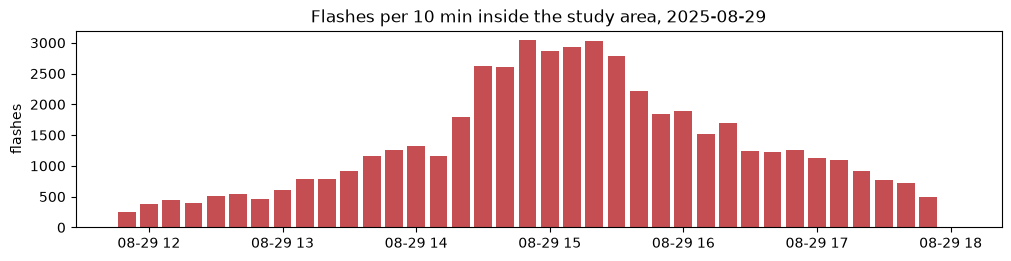

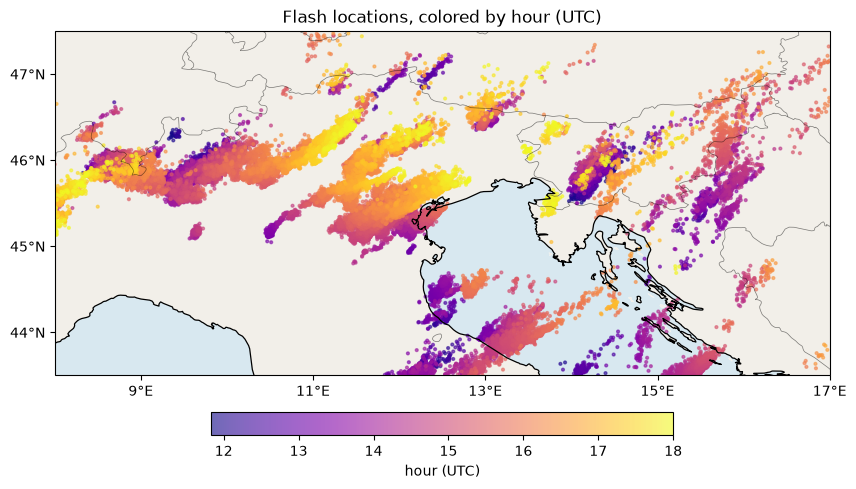

In [7]:
# When: the storm's life cycle in flashes per 10 min
fig1, ax1 = plt.subplots(figsize=(10, 2.5), layout="constrained")
counts = pd.Series(1, index=t).resample("10min").sum()
ax1.bar(counts.index, counts.values, width=pd.Timedelta("8min"), color="#c44e52")
ax1.set(title=f"Flashes per 10 min inside the study area, {STORM_DAY}", ylabel="flashes")

# Where: every flash at its coordinates, colored by hour
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

fig2 = plt.figure(figsize=(10, 6))
ax2 = fig2.add_subplot(projection=ccrs.PlateCarree())
ax2.set_extent([BBOX[0], BBOX[2], BBOX[1], BBOX[3]], crs=ccrs.PlateCarree())
ax2.add_feature(cfeature.OCEAN, facecolor="#d8e8f0")
ax2.add_feature(cfeature.LAND, facecolor="#f2efe9")
ax2.coastlines(resolution="10m", linewidth=0.9)
ax2.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.5)
sc = ax2.scatter(lon, lat, c=t.hour + t.minute / 60, s=4, cmap="plasma", alpha=0.6,
                 transform=ccrs.PlateCarree())
ax2.set_xticks([9, 11, 13, 15, 17], crs=ccrs.PlateCarree())
ax2.set_yticks([44, 45, 46, 47], crs=ccrs.PlateCarree())
ax2.xaxis.set_major_formatter(LongitudeFormatter())
ax2.yaxis.set_major_formatter(LatitudeFormatter())
ax2.set_title("Flash locations, colored by hour (UTC)")
cb = fig2.colorbar(sc, ax=ax2, orientation="horizontal", label="hour (UTC)",
                   fraction=0.05, pad=0.08)

### S3.2 The DEFAIR pipeline on one slot

Turning three heterogeneous products into one data cube takes four stages, and each stage is
`a single named DEFAIR call that works identically on any source`. That uniformity is the
point: the three products are processed with one line per stage, not with source specific
code.

| Stage | DEFAIR call | What it does |
|---|---|---|
| Read | `Dataset.from_source` | One call reads a file, a list of files (a time series), or a chunked FCI scene |
| Crop | `transform("spatial_filter", ...)` | Cuts the full disk down to the study area while the data is still lazy |
| Reproject | `transform("reprojection", ...)` | Puts every source on the same equal area grid (EPSG:3035, 2 km) |
| Align | `AlignmentPlugin` | Merges the reprojected sources into one dataset |

The walkthrough below applies  to a single 10 minute slot, the study window at 12:00 UTC
on the 6 June episode, so the effect of each stage is visible.

#### Stage 1: Read

One `(day, cycle)` pair identifies the same slot in the three products, and one wildcard call reads each of them. The pattern anchors the cycle between the underscores that delimit it in the MTG product name, so it matches exactly the files of that slot. The FCI scene arrives split into spatial chunk files and DEFAIR assembles them from the same pattern, with no list building and no chunk bookkeeping in the notebook. Nothing is loaded yet: the three datasets are lazy views of the full disc, identical except for the reader name.

In [8]:
# Stage 1: read the three sources of one slot (lazy)
day, cycle = "2025-06-16", "0073"
tag = day.replace("-", "")

# One wildcard call per source. The cycle is a delimited field of the MTG product name,
# so the pattern anchors it between underscores: an unanchored *cycle* would also match
# digits inside the timestamps and pull in files from neighbouring slots.
sources = {
    "FCI": Dataset.from_source(f"s3://{BUCKET}/fci-orig/*{tag}*_{cycle}_????.nc", # one call: the wildcard matches the slot's chunks, the reader assembles them
                               reader="mtg_fci_l1c_nc",
                               channels=["ir_105", "ir_123"], calibration="auto",
                               source="s3", source_kwargs=S3_SOURCE_KWARGS),
    "GII": Dataset.from_source(f"s3://{BUCKET}/gii-orig/*{tag}*_{cycle}_????.nc",
                               reader="mtg_l2_gii",
                               source="s3", source_kwargs=S3_SOURCE_KWARGS),
    "LI":  read_li_fixed(f"s3://{BUCKET}/li-orig/*{tag}*_{cycle}_????.nc"),   # temporary workaround, see S2
}
for name, ds in sources.items():
    print(f"{name:4s} {dict(ds.data.sizes)}")

/home/jovyan/envs/defair-04rc1/lib/python3.13/site-packages/defair_data/readers/mtg_fci/_fci_coordinate_cache.py:131: PerformanceWarning: Increasing number of chunks by factor of 21
  x_2d_lazy = da.blockwise(
/home/jovyan/envs/defair-04rc1/lib/python3.13/site-packages/defair_data/readers/mtg_fci/_fci_coordinate_cache.py:140: PerformanceWarning: Increasing number of chunks by factor of 21
  y_2d_lazy = da.blockwise(


FCI  {'time': 1, 'y_2km': 5568, 'x_2km': 5568}
GII  {'time': 1, 'y': 1856, 'x': 1856}
LI   {'time': 1, 'accumulations': 20, 'y': 269, 'x': 536}


#### Stage 2: Crop

The three datasets are still full disk grids, so this stage cuts each one down to the study
area before any heavier processing runs. The same `spatial_filter` call is applied to the
FCI 2 km imager grid and to the GII 6 km segment grid, even though the two grids are
completely different: that is the point of a named transformation, it does not care what
grid it is cropping. The LI window already arrives cropped, from the workaround in previous section (already reported), but
the same call would apply to it too.

In [9]:
# Stage 2: one identical spatial_filter call for the imager grids
cropped = {name: (ds.transform("spatial_filter", **crop) if name != "LI" else ds)
           for name, ds in sources.items()}
for name, ds in cropped.items():
    print(f"{name:4s} cropped: {dict(ds.data.sizes)}")

FCI  cropped: {'time': 1, 'y_2km': 269, 'x_2km': 536}
GII  cropped: {'time': 1, 'y': 88, 'x': 177}
LI   cropped: {'time': 1, 'accumulations': 20, 'y': 269, 'x': 536}


#### Stages 3 and 4: Reproject and align

EPSG:3035 is an equal area grid: every pixel covers the same ground area, which is what any
spatial statistic, or a convolutional model, expects. The three sources are reprojected onto
the same bounds and resolution (again, one identical size each) and the alignment plugin
merges them into a single dataset: **the cube**. Variable names keep a source prefix so their
origin stays visible; the FCI channels appear as `ch14` (10.5 µm) and `ch15` (12.3 µm). 

In [10]:
# Stages 3 and 4: reproject onto one shared grid, align into one cube
reproj = {name: ds.transform("reprojection", **common) for name, ds in cropped.items()}

cube_slot = AlignmentPlugin().transform(
    dataset=reproj["FCI"], datasets=[reproj["GII"], reproj["LI"]],
    target="EPSG:3035", target_resolution=2000.0, resolution_unit="meters",
)
slot = cube_slot.data
print("cube dims:", dict(slot.sizes))
print("cube vars:", list(slot.data_vars))
print("FCI dims: ", slot[BT].dims)                 # ('time', 'y', 'x')
print("LI dims:  ", slot[LI].dims)                 # ('time', 'accumulations', 'y', 'x')

cube dims: {'time': 1, 'x': 365, 'y': 234, 'accumulations': 20}
cube vars: ['mtg_fci_level_1c_netcdf_ch14', 'mtg_fci_level_1c_netcdf_ch15', 'mtg_fci_level_2_gii_pr_k_index', 'mtg_fci_level_2_gii_pr_lifted_index', 'mtg_fci_level_2_gii_pr_prec_water_total', 'mtg_fci_level_2_gii_pr_prec_water_low', 'mtg_fci_level_2_gii_pr_prec_water_mid', 'mtg_fci_level_2_gii_pr_prec_water_high', 'mtg_fci_level_2_gii_pr_percent_cloud_free', 'mtg_fci_level_2_gii_pr_number_of_iterations', 'li_flash_accumulation']
FCI dims:  ('time', 'y', 'x')
LI dims:   ('time', 'accumulations', 'y', 'x')


Running this pipeline shows the cube for one slot: two FCI channels, eight GII fields and the
raw LI accumulation now sit inside a single dataset, on a single grid, even though each
arrived on its own. Building the campaign cube (324 slots = 6 slot per hour x 6h x 9 days)
is exactly the same pipeline run again, once per slot, for all 36 slots of each of the nine episodes, with the per slot cubes then
concatenated along `time`. That loop, and the resumable persistence to Zarr that makes it
safe to interrupt and restart, is what the companion ingestion notebook automates; nothing
about the pipeline itself changes between one slot and the full campaign.

The dimensions and variable list printed above are what `Dataset.from_source` and the
alignment step actually produced for this one slot. Reading them is the first thing to do
with any new DEFAIR source: `dims` says how many positions each axis of the dataset has, and
`vars` says which physical fields are inside it.

The four dimensions are `time` (1, the single slot just built), `y` and `x` (234 by 365, the
study area at 2 km), and `accumulations` (20). This come from `li_flash_accumulation`, 
because the Lightning Imager delivers one 10-minute file as twenty 30-second sub windows, 
each a full `(y, x)` grid of flash counts. `dims` lists the union of all axes present in any variable,
which is why `accumulations` appears even though ten of the eleven variables never use it. The two `dims` lines printed
for FCI and LI make that visible.

The eleven variables split as two FCI channels (`ch14`, `ch15`, 10.5 and 12.3 µm brightness
temperature), eight GII fields and one LI field. Of the eight GII fields, three are used as
model inputs in CNN model (`k_index`, `lifted_index`, `prec_water_total`); the other five
(`prec_water_low`, `prec_water_mid`, `prec_water_high`, `percent_cloud_free`,
`number_of_iterations`) stay in the cube for inspection but are not fed to the network.

The figure below draws three of these variables side by side: the imager channel, the K index
and the lightning accumulation, all on the same grid. The LI variable still carries its
`accumulations` dimension (the twenty 30-second grids); they are summed here into the 10
minute total.

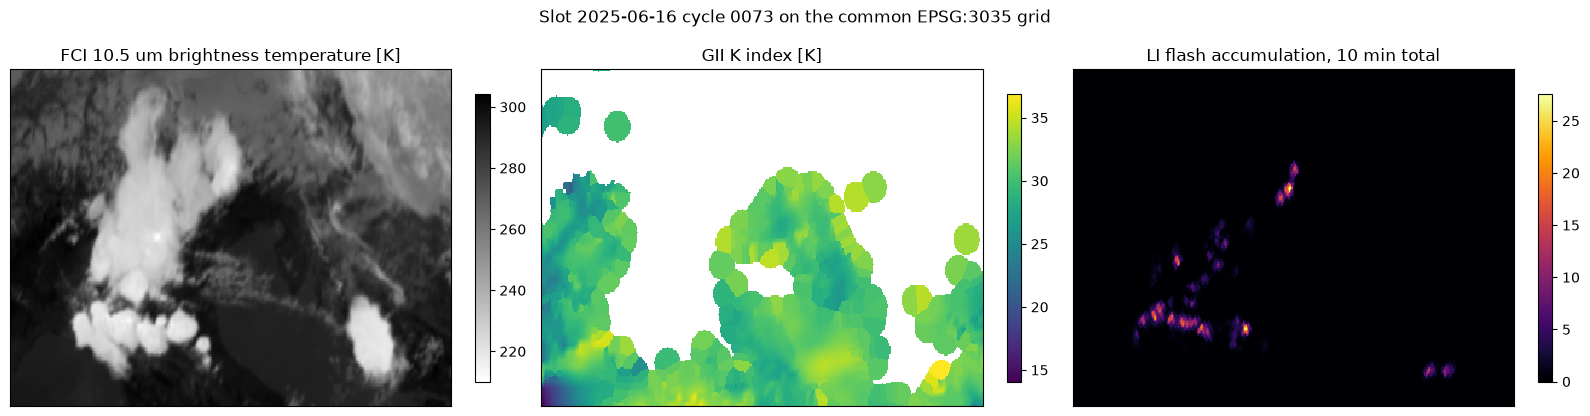

In [11]:
# S3.2 One grid, three products: the harmonized slot
extra_dims = [d for d in slot[LI].dims if d not in ("y", "x")]
li_total = slot[LI].sum(extra_dims) if extra_dims else slot[LI]   # 30 s accumulations to 10 min total
panels = [(slot[BT].squeeze(drop=True), "FCI 10.5 um brightness temperature [K]", "gray_r"),
          (slot["mtg_fci_level_2_gii_pr_k_index"].squeeze(drop=True), "GII K index [K]", "viridis"),
          (li_total, "LI flash accumulation, 10 min total", "inferno")]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True)
for ax, (field, title, cmap) in zip(axes, panels):
    field.plot(ax=ax, cmap=cmap, add_labels=False, cbar_kwargs={"fraction": 0.03})
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"Slot {day} cycle {cycle} on the common EPSG:3035 grid")
plt.tight_layout()

### S3.3 The campaign cube, straight from the bucket

The same four stages, applied to the 36 slots of each of the nine episodes and consolidated
along `time`, produce the **campaign cube**: 324 slots by 234 by 365 pixels by 11 variables,
about 290 MB. It was built once and located within the project's bucket, so it never needs to be
rebuilt: the single call below opens it directly from S3, and everything that follows in this
notebook works on it.

The cube was built by the companion notebook **`LightningCast_Ingestion.ipynb`**, which also
handles the data ingestion into the bucket. That notebook wraps the four stages of S3.2 in a
loop that runs once per slot, writes each result to Zarr as it goes so the run can be
interrupted and resumed, and finally consolidates the 324 slots and uploads the cube. It is
fully reproducible, but it takes several hours to complete.

One property of the cube matters for any later use: the time axis has gaps between episodes,
because the nine days are not contiguous. Any operation that looks across time steps
(temporal differences, future window labels) must be applied per episode, never across
episode boundaries.

In [12]:
# S3.3 Load the campaign cube from S3
storage_options = {
    "key": S3_SOURCE_KWARGS["aws_access_key_id"],
    "secret": S3_SOURCE_KWARGS["aws_secret_access_key"],
    "client_kwargs": {"endpoint_url": S3_SOURCE_KWARGS["endpoint_url"]},
}
cube = xr.open_zarr(f"s3://{BUCKET}/{PREFIX}cubes/lightningcast_cube.zarr",
                    storage_options=storage_options)

print(dict(cube.sizes), "|", len(cube.data_vars), "variables")
print("episodes:", sorted(set(str(d) for d in cube["time"].values.astype("datetime64[D]"))))

{'time': 324, 'y': 234, 'x': 365, 'accumulations': 20} | 11 variables
episodes: ['2025-06-16', '2025-06-21', '2025-06-26', '2025-07-06', '2025-07-26', '2025-08-02', '2025-08-20', '2025-08-29', '2025-09-16']


## What the cube enables: anatomy of a thunderstorm

Before the cube existed, answering any question about this storm meant starting from scratch
each time: download the files, open each product with its own reader, crop it, put it on a
common grid, and only then look at the data. Now that the three products share one grid and
one time axis, to asnwer those same questions it is quite straight forward, and the answer comes directly
from the cube. The two examples below use the same storm day 2025-08-29.

### The lightning footprint

This figure shows where lightning struck over the course of the storm afternoon. It is
obtained by summing the lightning variable of the cube, `li_flash_accumulation`, over every
10 minute slot of the day, so each pixel counts how many flashes the Lightning Imager
accumulated there between 12:00 and 18:00 UTC. The result is the storm's footprint: the
tracks of the organized convective systems as they moved across the Po Valley toward the
Adriatic, already on the 2 km analysis grid where the rest of the cube lives.

What makes this map worth pausing on is how little work it took. The flash data inside the
cube arrived as twenty 30-second accumulation grids per file, on the Lightning Imager's own
projection, one file per slot. DEFAIR read those files, cropped them, reprojected them onto
the common equal area grid and aligned them with the FCI and GII fields into a single
dataset. From there, turning 36 slots of raw lightning observations into a daily footprint is
a one line xarray sum. Without the cube, the same map would mean writing a dedicated LI
decoder, a reprojection step and a time aggregation loop before plotting anything. The
footprint is also the variable the model in the CNN step will predcit, so seeing it here
first makes clear what the network is being asked to.

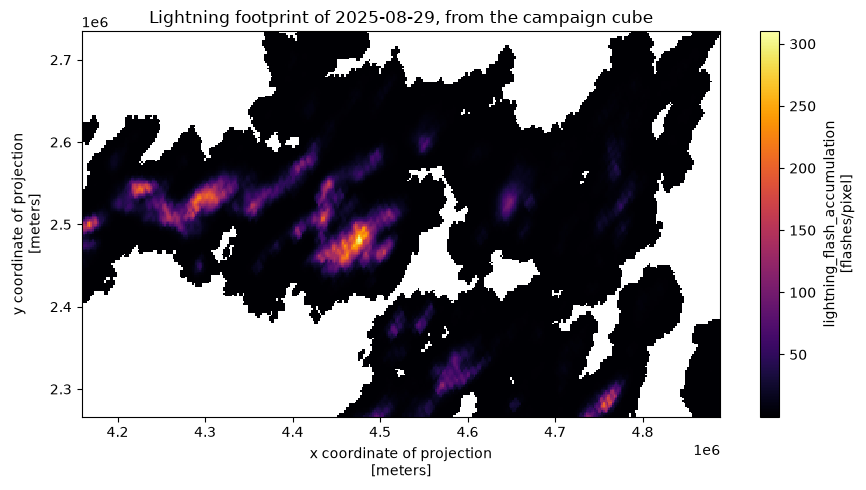

In [13]:
# Lightning footprint of the storm day, from the cube
storm = cube.sel(time=slice(STORM_DAY, STORM_DAY + "T23:59"))
footprint = storm[LI].sum("time").compute()

fig, ax = plt.subplots(figsize=(9, 5))
footprint.where(footprint > 0).plot(ax=ax, cmap="inferno")
ax.set_title(f"Lightning footprint of {STORM_DAY}, from the campaign cube")
plt.tight_layout()

### The premise of LightningCast, in one figure

Each panel shows the storm from above at one moment of the afternoon. The grey background is
cloud top temperature from the FCI 10.5 µm channel, where bright means cold and therefore
tall, vigorous cloud. The red and yellow patches are the lightning the Lightning Imager
detected in that same 10 minute slot.

The point is visible at a glance: lightning sits on the brightest, coldest cloud tops, and as
those tops grow and spread through the afternoon the lightning grows with them. That link
between what the imager sees and where lightning occurs is the whole premise of
LightningCast, and the one the U Net in next session will learn to anticipate one hour ahead.

Drawing this takes two lines per panel because FCI and LI are already in the same cube, on
the same grid and the same time axis. Selecting one slot with `storm.sel(time=...)` returns
both fields aligned pixel for pixel, ready to overlay. Without DEFAIR the same figure would
mean reading two products with two different decoders, reprojecting each to a common grid
and matching their time stamps by hand before a single pixel could be plotted.

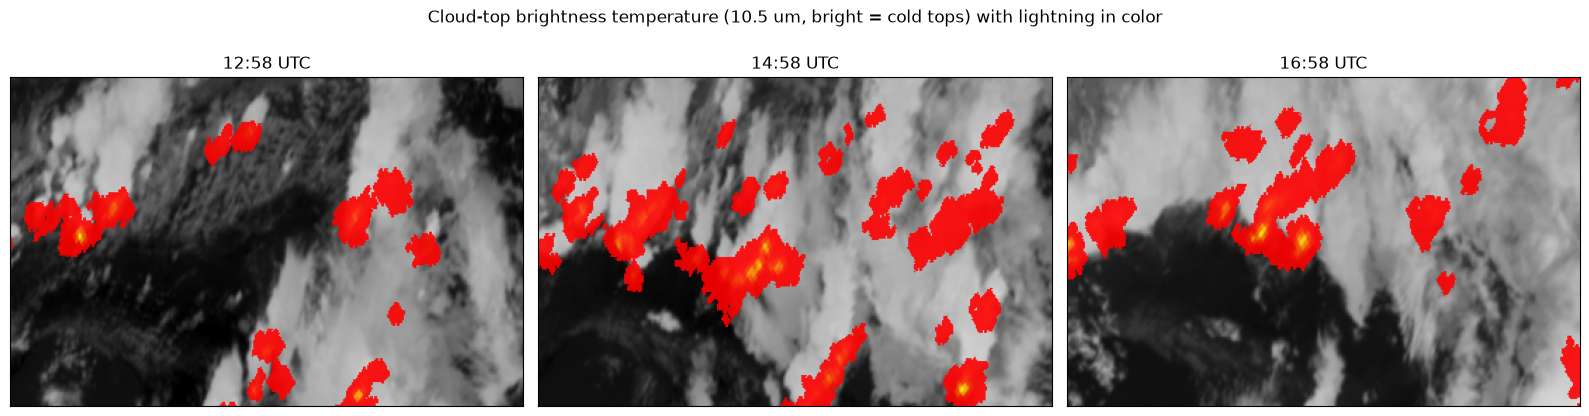

In [14]:
# Cloud-top temperature with lightning overlaid, at three moments of the storm
moments = [f"{STORM_DAY}T13:00", f"{STORM_DAY}T15:00", f"{STORM_DAY}T17:00"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, moment in zip(axes, moments):
    s = storm.sel(time=moment, method="nearest")
    bt = s[BT].values
    li = np.ma.masked_less_equal(np.nan_to_num(s[LI].values), 0)   # only pixels with lightning are drawn
    ax.imshow(bt, cmap="gray_r", vmin=200, vmax=300, origin="upper")
    ax.imshow(li, cmap="autumn", alpha=0.9, origin="upper")
    ax.set_title(str(s["time"].values)[11:16] + " UTC")
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Cloud-top brightness temperature (10.5 um, bright = cold tops) with lightning in color")
plt.tight_layout()

## Deep learning application: lightning nowcasting with a U Net

This section shows, as briefly as possible, that the campaign cube can be consumed by a real
application without any further data engineering: a convolutional network that receives the
cube's own frames as input and learns to anticipate where lightning will occur in the next
hour, following the LightningCast concept of Cintineo et al. (2022).

The model is deliberately minimal. Its purpose is to demonstrate the bridge between the
AI ready cube and a deep learning model, not to reach that operational skill. Four simplifications
follow from that goal, and each is a declared methodological choice rather than an omission:
the inputs are six cube variables taken as they are, without normalisation statistics; the
label is a binary flag for any lightning in the next hour; every training sample is a full
frame of the cube rather than a sampled patch; and the split is eight episodes for training
against a single held out test day. Each choice is explained where it is made.

### From the cube to tensors

The **inputs** at time *t* are the two FCI brightness temperatures (10.5 and 12.3 µm), the
ten minute tendency of the 10.5 µm channel, and three GII fields (K index, Lifted Index,
total precipitable water; the layered water fields stay in the cube as a possible extension).
The tendency is a single `.diff("time")` computed within each episode, so the first slot of
each episode is dropped. No normalisation statistics are computed: the network 
includes batch normalisation, which absorbs the different physical scales of the six inputs.

The **label** at time *t* is binary: whether the LI flash accumulation, summed over the six
following slots of the same episode (*t* plus 10 minutes to *t* plus 60 minutes), reaches
**one flash**. One flash is the physical unit of the variable, not a tuned threshold, and it
matters here: the LI field is reprojected bilinearly, which spreads a faint halo of
fractional values around every flash; with a rule of any value above zero, 21 percent of the
training pixels came out positive, two thirds of them below one flash, whereas the one flash
rule gives about 7 percent in training and 1 percent in the test day. The last six slots of
each episode have no complete future window and are dropped. Because the cube's time axis has
gaps between episodes, both the tendency and the label are computed episode by episode and
never across a boundary.

Each **sample is a full frame** of the cube (234 by 365 pixels), not a random patch. Only the
seven variables actually needed (five inputs, the brightness temperature used for the
tendency, and the label) are loaded from the cube, and the tensor is built as
`(slot, variable, y, x)`: this is what makes the **AI readiness of the cube visible**. Missing
values (GII retrievals over cloud, grid edges) are set to zero after the tendency and the
label are computed. The split is by episode: eight episodes for training and the temporally
isolated 2025-09-16 for testing.

In [15]:
# S5.From the cube to tensors: inputs at t, lightning label at t+1h
import torch                                       # the deep learning dependency enters the notebook here

INPUTS  = [BT, "mtg_fci_level_1c_netcdf_ch15",      # BT first: S6 plots channel 0 as the input
           "mtg_fci_level_2_gii_pr_k_index", "mtg_fci_level_2_gii_pr_lifted_index",
           "mtg_fci_level_2_gii_pr_prec_water_total"]
HORIZON = 6                                        # six 10 min slots = the next hour

def frames_of(day):
    """One episode to (X, Y): X = inputs and BT tendency at t, Y = lightning in t+1h."""
    ep = cube[INPUTS + [LI]].sel(time=slice(day, day + "T23:59")).compute()   # only the 7 variables needed
    x  = np.concatenate([ep[INPUTS].to_array().values,                  # (5, time, y, x)
                         ep[BT].diff("time").pad(time=(1, 0)).values[None]], axis=0)
    li = ep[LI].values
    y  = np.stack([li[t + 1 : t + 1 + HORIZON].sum(0) >= 1 for t in range(len(li))])   # one flash rule
    keep = slice(1, len(li) - HORIZON)             # drop the first slot (no tendency) and the last six (no future)
    x = np.nan_to_num(np.moveaxis(x[:, keep], 0, 1))                    # (slot, 6, y, x)
    return x.astype("float32"), y[keep, None].astype("float32")         # (slot, 1, y, x)

Xtr, Ytr = map(np.concatenate, zip(*[frames_of(d) for d in TRAIN_EPISODES]))
Xte, Yte = map(np.concatenate, zip(*[frames_of(d) for d in TEST_EPISODES]))
Xtr, Ytr, Xte, Yte = map(torch.from_numpy, (Xtr, Ytr, Xte, Yte))
print("train", tuple(Xtr.shape), "| test", tuple(Xte.shape),
      f"| positive pixels: {100 * Ytr.mean():.2f}% train, {100 * Yte.mean():.2f}% test")

train (232, 6, 234, 365) | test (29, 6, 234, 365) | positive pixels: 6.79% train, 1.26% test


### A minimal U Net, trained on full frames

The network is a minimal two level U Net that outputs one logit per pixel, the probability (after a sigmoid) of lightning in the next hour at that location; its structure is fully visible in the code below. The class imbalance is handled through a single positive class weight in the loss, computed from the training label itself (roughly 14: one positive pixel for every fourteen negative ones). Ten epochs with Adam on the two CPU cores of the pod take about eight minutes, and the random seed is fixed so the run is repeatable.

In [16]:
# A minimal U-Net, trained on full frames
import torch.nn as nn
torch.manual_seed(0); torch.set_num_threads(2)      # repeatable run; the pod has 2 CPU cores

def block(c_in, c_out):
    return nn.Sequential(nn.Conv2d(c_in, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU(),
                         nn.Conv2d(c_out, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU())

class UNet(nn.Module):
    """Two level U-Net: encode, downsample, decode with a skip connection, one logit per pixel."""
    def __init__(self, c_in=6, base=16):
        super().__init__()
        self.e1, self.e2 = block(c_in, base), block(base, base * 2)
        self.pool = nn.MaxPool2d(2)
        self.d1, self.head = block(base * 3, base), nn.Conv2d(base, 1, 1)
    def forward(self, x):
        s1 = self.e1(x)
        s2 = self.e2(self.pool(s1))
        up = nn.functional.interpolate(s2, size=s1.shape[-2:], mode="nearest")   # exact size: frames are odd
        return self.head(self.d1(torch.cat([up, s1], dim=1)))

model = UNet()
pos_weight = (1 - Ytr.mean()) / Ytr.mean()          # weight of the rare positive class
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS, BATCH = 10, 8
for epoch in range(EPOCHS):
    start, perm, losses = time.time(), torch.randperm(len(Xtr)), []
    for i in range(0, len(Xtr), BATCH):
        idx = perm[i:i + BATCH]
        opt.zero_grad(); loss = loss_fn(model(Xtr[idx]), Ytr[idx]); loss.backward(); opt.step()
        losses.append(loss.item())
    print(f"epoch {epoch + 1:2d}/{EPOCHS} | mean loss {np.mean(losses):.3f} | {time.time() - start:.0f} s")

epoch  1/10 | mean loss 1.023 | 53 s
epoch  2/10 | mean loss 0.884 | 52 s
epoch  3/10 | mean loss 0.813 | 51 s
epoch  4/10 | mean loss 0.765 | 52 s
epoch  5/10 | mean loss 0.727 | 52 s
epoch  6/10 | mean loss 0.700 | 52 s
epoch  7/10 | mean loss 0.688 | 51 s
epoch  8/10 | mean loss 0.664 | 51 s
epoch  9/10 | mean loss 0.645 | 52 s
epoch 10/10 | mean loss 0.649 | 51 s


### Evaluation on the held out episode

The trained network is applied to the 29 useful slots of 2025-09-16 and its probabilities are turned into a yes or no forecast at the 0.5 threshold. Comparing forecast and observed lightning pixel by pixel gives the three scores LightningCast itself reports: the probability of detection (POD, the fraction of observed lightning pixels that were forecast), the false alarm ratio (FAR, the fraction of forecast pixels where no lightning followed) and the critical success index (CSI, hits over hits plus misses plus false alarms, the single summary score).

In [17]:
# Evaluation on the held-out episode: POD, FAR, CSI
model.eval()
with torch.no_grad():
    prob = torch.sigmoid(model(Xte))                 # (slot, 1, y, x) probabilities
pred, obs = prob >= 0.5, Yte.bool()

hits, misses, false = (pred & obs).sum(), (~pred & obs).sum(), (pred & ~obs).sum()
POD, FAR, CSI = hits / (hits + misses), false / (hits + false), hits / (hits + misses + false)
print(f"{TEST_EPISODES[0]} | POD {POD:.2f} | FAR {FAR:.2f} | CSI {CSI:.2f} "
      f"| forecast lightning area {100 * pred.float().mean():.1f}% vs observed {100 * obs.float().mean():.1f}%")

2025-09-16 | POD 0.29 | FAR 0.96 | CSI 0.04 | forecast lightning area 8.4% vs observed 1.3%


## Results and limitations

The figure below shows the test day, 2025-09-16, at the peak of its afternoon activity: what the network sees, what it forecasts for the next hour, and what the Lightning Imager actually recorded.

Over the whole test day the model reaches a POD of 0.29, a FAR of 0.96 and a CSI of 0.04, forecasting lightning on 8.4 percent of the domain against 1.3 percent observed (a rerun may differ slightly: CPU training is not fully deterministic). The network has learnt the right relationship, its probability follows the cold, deepening cloud tops, but it over forecasts heavily, the expected price of the simplifications declared previously: 232 training frames is a very small sample, a positive class weight of about 14 pushes the network toward false alarms, ten epochs on two CPU cores is minutes of training against days of GPU training for the operational LightningCast, and a single test day makes the scores indicative rather than robust. None of these limits come from the data: the cube supports more episodes, patch sampling and longer training without any change to the pipeline.

Everything upstream in this section is independent of the model: the same cube can feed any other architecture without touching the pipeline. That is what an AI ready cube built with DEFAIR is for.

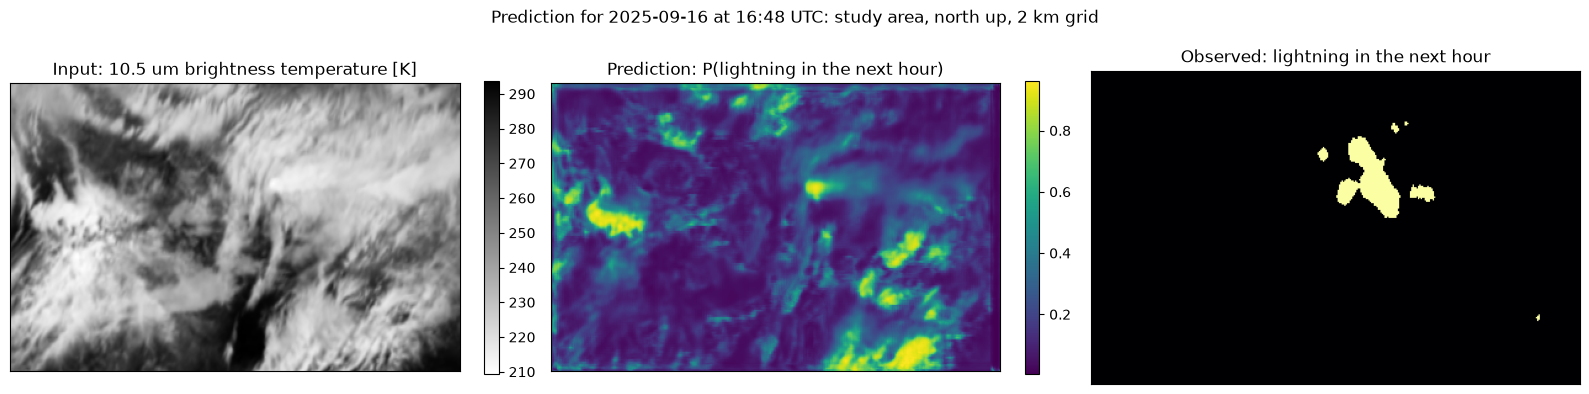

In [18]:
# Model prediction on the most active slot of the test day
i = int(Yte.sum(dim=(1, 2, 3)).argmax())                        # slot with the most observed lightning
slot_time = cube.sel(time=slice(TEST_EPISODES[0], TEST_EPISODES[0] + "T23:59"))["time"].values[i + 1]
slot_utc  = str(slot_time)[11:16]                                # S5.1 drops the first slot of the day, hence i + 1

panels = [(Xte[i, 0],  "Input: 10.5 um brightness temperature [K]", "gray_r"),
          (prob[i, 0], "Prediction: P(lightning in the next hour)", "viridis"),
          (Yte[i, 0],  "Observed: lightning in the next hour",      "inferno")]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True)
for k, (ax, (field, title, cmap)) in enumerate(zip(axes, panels)):
    im = ax.imshow(field.numpy(), cmap=cmap, origin="upper")
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
    if k < 2:
        plt.colorbar(im, ax=ax, fraction=0.03)
fig.suptitle(f"Prediction for {TEST_EPISODES[0]} at {slot_utc} UTC: study area, north up, 2 km grid")
plt.tight_layout()

## Conclusions

This notebook set out to demonstrate that DEFAIR can carry a real scientific application, satellite based lightning nowcasting, from raw multi source data to a working deep learning prototype. What the journey showed about DEFAIR:

- **One interface, any product.** Five different MTG products (FCI L1C chunked imagery, GII Level 2 fields, LI AF gridded accumulations, LI LFL point records) were read with the same `Dataset.from_source` call, changing only the reader name. No custom netCDF parsing was written anywhere in the notebook.

- **Named transformations replace adapted pipelines.** Cropping, reprojection and alignment are single calls that behave identically on a 2 km imager grid, a 6 km segment grid and a lightning accumulation grid. The full harmonization of one slot is four stages, one line each.

- **The cube is the deliverable.** 324 slots, 11 variables, one grid, one time axis, built once and published to S3. Every analysis in S4 became a few lines of xarray, and the deep learning inputs of S5 are the cube itself reordered into tensors, with no intermediate data engineering.

- **AI readiness is model independence.** The U Net is deliberately minimal; its modest scores are the declared price of that choice, not a data limit. The same cube can feed any other architecture, at any training scale, without touching the pipeline.

The companion notebook, `LightningCast_Ingestion.ipynb`, documents how the cube was built and makes the whole chain reproducible end to end.

## Resources and references

Cintineo, J. L., Pavolonis, M. J., & Sieglaff, J. M. (2022). ProbSevere LightningCast: A Deep Learning Model for Satellite Based Lightning Nowcasting. *Weather and Forecasting*, 37(7), 1239 to 1257. [https://doi.org/10.1175/WAF-D-22-0019.1](https://doi.org/10.1175/WAF-D-22-0019.1)

**EUMETSAT product documentation**

The official data guides on the EUMETSAT User Portal describe each product used in this notebook: the [MTG FCI Level 1c data guide](https://user.eumetsat.int/resources/user-guides/mtg-fci-level-1c-data-guide) for the imager radiances, the [MTG FCI L2 GII data guide](https://user.eumetsat.int/resources/user-guides/mtg-fci-l2-gii-data-guide) for the Global Instability Index, the [MTG LI Level 2 data guide](https://user.eumetsat.int/resources/user-guides/mtg-li-level-2-data-guide) for the Lightning Imager flash and accumulated products, and the [MTG data access guide](https://user.eumetsat.int/resources/user-guides/mtg-data-access-guide) for how to obtain the data.

**Destination Earth DataLake**

Data discovery and access in this project use the Harmonised Data Access STAC API at [https://hda.data.destination-earth.eu](https://github.com/destination-earth/DestinE-DataLake-Lab/tree/main/HDA), the DataLake S3 object store at [https://s3.central.data.destination-earth.eu](https://s3.central.data.destination-earth.eu), and the DestinE JupyterHub where this notebook runs. The [DestinE DataLake Lab repository](https://github.com/destination-earth/DestinE-DataLake-Lab) collects the official access notebooks this project builds on.

**DEFAIR**

This notebook uses DEFAIR 0.4.0rc1 (`defair-04rc1` kernel). The framework provides the `Dataset.from_source` readers, the `defair_ops` transformations and the alignment plugin used throughout.